
# Chapter 10 — Introduction to Graph Neural Networks (GNNs)

Every method in the last three chapters worked the same way: **build a feature
table first, then hand it to a classifier.** In Chapters 2–3 and 7 we *engineered*
the columns by hand — degree, clustering, the centralities. In Chapter 8 we
*learned* them with Node2Vec. Chapter 9 fed both kinds of column to a logistic
regression and a random forest. In all of them, the step that touches the graph
("make features") and the step that makes the prediction ("classify") are two
separate machines, glued together by us.

This chapter introduces the tool that **fuses those two steps into one trainable
model**: the **graph neural network (GNN)**. A GNN does not wait for us to design
features — it *learns* them, directly from the graph, by a single repeating move
called **message passing**: every node mixes its own vector with its neighbours'.
Stack a couple of those moves, train the whole thing against the labels, and the
features and the classifier are tuned together, end to end.

> **The spine of this chapter:** *can a model learn its own node features straight
> from the graph, instead of us building them by hand?* We answer yes — and we
> build the simplest such model, the **Graph Convolutional Network (GCN)**, from
> scratch.

We pick up exactly where Chapter 9 left off ("Chapter 10 stops hand-designing
features altogether") and where Chapter 7 deferred the details (§7.6 used a GCN as
a *black box* and promised it would be "covered in depth in Chapter 10"). We use
the same dataset as those chapters — the **Cora** citation network — so every
number here is comparable to what came before.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, classification_report

from torch_geometric.datasets import Planetoid

# One seed for the whole chapter — GNN training is stochastic, so pin it down.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 10.1 The feature you didn't have to build

Recall the pipeline that carried us through Chapters 7–9:

```
graph ──▶ [ make features ]  ──▶  feature table  ──▶ [ classifier ] ──▶ prediction
            (by hand, or                              (logreg, RF,
             Node2Vec)                                 we picked it)
```

Everything to the left of the table is *our* labour and *our* guesswork. We chose
which structural measurements to compute; we chose Node2Vec's walk length. The
classifier never sees the graph — only the table we distilled from it.

A GNN replaces that whole chain with **one model that reads the graph directly**
and is trained against the labels in a single pass:

```
graph ──▶ [        graph neural network         ] ──▶ prediction
              (learns its own features by
               passing messages along edges)
```

To see this on real data we return to **Cora** — the citation network from §7.2,
where each node is a machine-learning paper, each edge a citation, and each paper
carries a **1,433-word bag-of-words** record of its content plus one of **7 topic
labels**.


In [2]:
cora = Planetoid(root="/tmp/CoraFull", name="Cora")
data = cora[0]          # a single PyG `Data` object: tensors, not a NetworkX graph
N = data.num_nodes

class_names = {
    0: "Case-Based",
    1: "Genetic Algorithms",
    2: "Neural Networks",
    3: "Probabilistic Methods",
    4: "Reinforcement Learning",
    5: "Rule Learning",
    6: "Theory",
}

print(f"Nodes (papers)        : {N:,}")
print(f"Edges (citations)     : {data.num_edges:,}")
print(f"Content features/node : {cora.num_node_features:,}  (bag-of-words)")
print(f"Topic classes         : {cora.num_classes}")
print()
print(f"Labeled for TRAINING  : {int(data.train_mask.sum()):>5}")
print(f"Held out for VALIDATION: {int(data.val_mask.sum()):>4}")
print(f"Held out for TEST     : {int(data.test_mask.sum()):>5}")


Nodes (papers)        : 2,708
Edges (citations)     : 10,556
Content features/node : 1,433  (bag-of-words)
Topic classes         : 7

Labeled for TRAINING  :   140
Held out for VALIDATION:  500
Held out for TEST     :  1000


Processing...
Done!


Look at the last three numbers. Of **2,708** papers, only **140** come with a
label the model may learn from; the rest are unlabelled. This is the normal
situation for graph data — labelling is expensive, edges are cheap — and it has a
name: **semi-supervised** learning. A GNN thrives here precisely because it can
**propagate** the few labels it has along the edges to the many nodes it cannot
see directly.

How are those 140 training labels distributed? Cora's standard split gives each
topic an equal share.


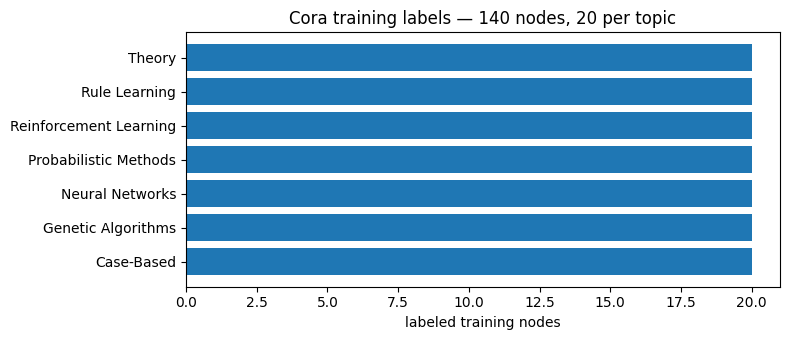

Fraction of all papers that are labeled for training: 5.2%


In [3]:
train_y = data.y[data.train_mask].numpy()
per_class = np.bincount(train_y, minlength=cora.num_classes)

plt.figure(figsize=(8, 3.5))
plt.barh([class_names[i] for i in range(cora.num_classes)], per_class, color="C0")
plt.xlabel("labeled training nodes")
plt.title(f"Cora training labels — {per_class.sum()} nodes, {per_class[0]} per topic")
plt.tight_layout()
plt.show()

print(f"Fraction of all papers that are labeled for training: "
      f"{data.train_mask.float().mean():.1%}")


### 🖐️ Your turn: how much supervision?

The model trains on `data.train_mask` but is *scored* on `data.test_mask`.

In [4]:
# 🖐️ Print the fraction of papers in the TEST set, and how many test papers
#    there are per labeled training paper. (A GNN learns from 140 and is judged
#    on 1,000 — that ratio is the whole challenge.)
# Hint: data.test_mask.float().mean() gives the test fraction.
# TODO: print the test fraction and the ratio (# test) / (# train).


## 10.2 Message passing: a node is the company it keeps

The one idea behind every GNN is almost embarrassingly simple. To update a node,
**look at its neighbours and summarise them.** Do it again, and each node now
reflects its neighbours' neighbours. Do it $k$ times and a node has "heard from"
everyone within $k$ hops. That repeating move is **message passing**.

Let us watch it on a tiny graph where we can track every number by hand. Each node
starts with a single feature value; one round of message passing replaces each
value with the **mean of its neighbours'** values (a *mean aggregator*).


In [ ]:
# Give every node a starting feature value the moment we build the graph,
# and store it on the node itself (a fixed seed keeps the numbers reproducible).
rng = np.random.default_rng(7)
G_toy = nx.Graph()
G_toy.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4)])
nx.set_node_attributes(
    G_toy,
    {n: round(float(rng.random()), 2) for n in sorted(G_toy.nodes())},
    name="x",
)

pos_toy = nx.spring_layout(G_toy, seed=1)
plt.figure(figsize=(4.5, 3.5))
nx.draw_networkx(G_toy, pos_toy, node_color="C1", node_size=700,
                 font_color="white", font_weight="bold")
# Print each node's feature just above-right of the node, beside its number.
feat_pos = {n: (x + 0.14, y + 0.12) for n, (x, y) in pos_toy.items()}
nx.draw_networkx_labels(
    G_toy, feat_pos,
    labels={n: f"x={G_toy.nodes[n]['x']}" for n in G_toy.nodes()},
    font_size=9, font_color="C0")
plt.title("A 5-node toy graph (node id + starting feature)")
plt.margins(0.18)
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Read back the starting features we attached when building the graph.
feat0 = dict(nx.get_node_attributes(G_toy, "x"))
print("Initial features:", feat0)


def mean_pass(G, feats):
    """One round of message passing with a mean aggregator."""
    new = {}
    for node in G.nodes():
        nbrs = list(G.neighbors(node))
        new[node] = np.mean([feats[m] for m in nbrs]) if nbrs else feats[node]
    return new


history = [dict(feat0)]
cur = dict(feat0)
for _ in range(6):
    cur = mean_pass(G_toy, cur)
    history.append(dict(cur))

# Plot how each node's value evolves round by round.
plt.figure(figsize=(7, 4))
for node in sorted(G_toy.nodes()):
    plt.plot(range(len(history)), [h[node] for h in history],
             marker="o", label=f"node {node}")
plt.xlabel("message-passing round")
plt.ylabel("feature value")
plt.title("Features diffuse across the graph")
plt.legend()
plt.tight_layout()
plt.show()

print("After 1 round:", {k: round(v, 2) for k, v in history[1].items()})


**By hand.** Node 0's neighbours are nodes 1 and 2, which start at
$0.90$ and $0.78$. So after one round node 0 becomes
$\tfrac{1}{2}(0.90 + 0.78) = 0.84$ — exactly the value printed above.

```mermaid
flowchart LR
    n1["node 1 = 0.90"] --> agg(("mean"))
    n2["node 2 = 0.78"] --> agg
    agg --> n0["node 0<br/>next round = 0.84"]
```

Two things to notice in the plot:

- **Information spreads.** After round 1 a node knows its immediate neighbours;
  after round 2, its 2-hop neighbourhood; and so on. **Rounds = reach.**
- **The values drift together.** Repeated averaging is *smoothing* — push it far
  enough and every node converges to nearly the same number. Hold that thought:
  it is the blessing of message passing (nearby nodes come to agree) and, taken
  too far, its curse (§10.5).

> **A GNN is built from one move repeated: replace each node's vector with a
> summary of its neighbours', then mix in a learnable transform.**


### 🖐️ Your turn: predict before you run

Node 4 sits at the end of the chain.

In [7]:
# 🖐️ Without running message passing, predict node 4's value after ONE round,
#    then check it against history[1].
# Hint: list node 4's neighbours with list(G_toy.neighbors(4)); a mean over one
#       neighbour is just that neighbour's starting value.
# TODO: print your predicted value for node 4 and compare to history[1][4].


### 🖐️ Your turn: watch it flatten out

We ran 6 rounds. What happens with many more?

In [8]:
# 🖐️ Run mean_pass for, say, 30 rounds and print the final values. How close are
#    the five nodes to each other now? (This previews "over-smoothing" in §10.5.)
# Hint: copy the loop above but iterate 30 times; compare max(values) - min(values).
# TODO: print the spread (max - min) of the node values after 30 rounds.


## 10.3 From smoothing to a graph convolution

Plain neighbour-averaging is a fine intuition but a poor layer, for two reasons —
each with a standard fix.

**Problem 1 — a node forgets itself.** Our `mean_pass` averaged *only* the
neighbours, so a node's own value vanished after one step. The fix is a
**self-loop**: let every node be its own neighbour. In matrix terms, work with
$\tilde{A} = A + I$ (the adjacency matrix plus the identity).

**Problem 2 — high-degree nodes shout.** If we simply *sum* neighbours, a hub with
500 links produces a value 500× larger than a leaf's, and the scale explodes as we
stack layers. We need to **normalise by degree**. The GCN's choice is *symmetric*
normalisation: divide each edge's contribution by $\sqrt{d_i}\,\sqrt{d_j}$ — the
square-root of *both* endpoints' degrees. A message from a popular node is
discounted (it talks to everyone), and so is a message *into* a popular node.

Put together, the **graph convolution** propagates features with the **normalised
adjacency**

$$\hat{A} \;=\; \tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2},
\qquad \tilde{A} = A + I,$$

where $\tilde{D}$ is the diagonal degree matrix of $\tilde{A}$. Here is $\hat{A}$
for our toy graph — one number per pair of nodes, telling each node how much of
every neighbour (and itself) to absorb.


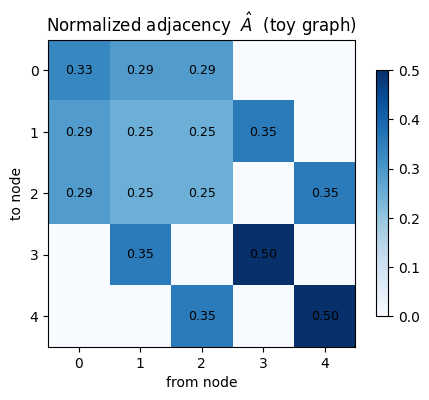

In [9]:
nodes_toy = sorted(G_toy.nodes())
A = nx.to_numpy_array(G_toy, nodelist=nodes_toy)
A_tilde = A + np.eye(len(nodes_toy))                 # add self-loops
deg = A_tilde.sum(axis=1)
D_inv_sqrt = np.diag(deg ** -0.5)
A_hat_toy = D_inv_sqrt @ A_tilde @ D_inv_sqrt        # symmetric normalization

plt.figure(figsize=(4.8, 4))
plt.imshow(A_hat_toy, cmap="Blues")
for i in range(len(nodes_toy)):
    for j in range(len(nodes_toy)):
        if A_hat_toy[i, j] > 0:
            plt.text(j, i, f"{A_hat_toy[i, j]:.2f}", ha="center", va="center",
                     color="black", fontsize=9)
plt.xticks(range(len(nodes_toy)), nodes_toy)
plt.yticks(range(len(nodes_toy)), nodes_toy)
plt.xlabel("from node"); plt.ylabel("to node")
plt.title(r"Normalized adjacency  $\hat{A}$  (toy graph)")
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()


Each row of $\hat{A}$ sums (roughly) to one and the diagonal is non-zero — every
node keeps a share of itself and blends in a degree-weighted share of its
neighbours. Multiplying a feature matrix by $\hat{A}$ is exactly the "mix with
your neighbours" move from §10.2, now self-aware and degree-fair.

A single **GCN layer** does two things — propagate, then transform:

$$H' \;=\; \sigma\!\big(\hat{A}\,H\,W\big),$$

where $H$ is the current node features, $W$ is a **learnable** weight matrix (this
is the part that gets trained), and $\sigma$ is a nonlinearity such as ReLU.
**Stacking** layers widens the reach: two layers let each node see its **2-hop**
neighbourhood. That is the whole architecture.

> **A GCN layer = average with your (degree-normalised, self-included) neighbours,
> then apply a trained linear map. Depth = how many hops a node can see.**

Before we code it, here is that layer as a picture.


Here is that single layer as a picture. Read the boxes left to right — which is
exactly the code order `A_hat @ self.linear(H)`: transform first with the trainable
weights, then propagate along the edges, then squash.

```mermaid
flowchart LR
    H["H<br/>current features"] --> W["multiply by W<br/>learnable linear map"]
    W --> Ahat["multiply by Â<br/>propagate along edges"]
    Ahat --> S["σ (ReLU)"]
    S --> Hp["H'<br/>updated features"]
    style W fill:#d1e7dd,stroke:#0f5132
    style Ahat fill:#cfe2ff,stroke:#084298
```

Only the green box, $W$, is **learned**; the blue box, $\hat{A}$, is **fixed by the
graph**. **Stacking** two of these layers is what widens a node's view: after
layer 1 it has mixed with its 1-hop neighbours, after layer 2 with its 2-hop
neighbourhood. *Depth buys reach.* Below we implement exactly this in a few lines
of PyTorch, then build $\hat{A}$ for the full Cora graph.


In [10]:
class GCNLayer(nn.Module):
    # H' = A_hat @ (H W).  We transform first, then propagate — algebraically the
    # same as A_hat @ H @ W, but cheaper because the propagation acts on the
    # smaller transformed matrix.
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, H, A_hat):
        return A_hat @ self.linear(H)


class GCN(nn.Module):
    def __init__(self, nfeat, nhid, nclass):
        super().__init__()
        self.gcn1 = GCNLayer(nfeat, nhid)
        self.gcn2 = GCNLayer(nhid, nclass)

    def forward(self, X, A_hat):
        h = F.relu(self.gcn1(X, A_hat))   # layer 1: 1-hop mixing + ReLU
        out = self.gcn2(h, A_hat)         # layer 2: 2-hop mixing -> class scores
        return out, h                     # also return the hidden embeddings


# Build A_hat for Cora from the edge list — the same recipe as the toy graph.
A = torch.zeros((N, N))
A[data.edge_index[0], data.edge_index[1]] = 1.0
A = ((A + A.t()) > 0).float()             # ensure symmetric & binary
A_tilde = A + torch.eye(N)                # self-loops
deg = A_tilde.sum(1)
D_inv_sqrt = torch.diag(deg.pow(-0.5))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
print("A_hat:", tuple(A_hat.shape), "  non-zero entries:", int((A_hat > 0).sum()))


A_hat: (2708, 2708)   non-zero entries: 13264


## 10.4 Training a GCN on Cora — and does the graph help?

Now we train. The recipe is ordinary supervised learning: a forward pass produces
class scores for *every* node, we compute the cross-entropy loss **only on the 140
labelled training nodes**, and back-propagation nudges the weights. We track
accuracy on the held-out validation set as we go, and report the final number on
the untouched **test** set.


GCN  —  test accuracy 0.808   macro-F1 0.802


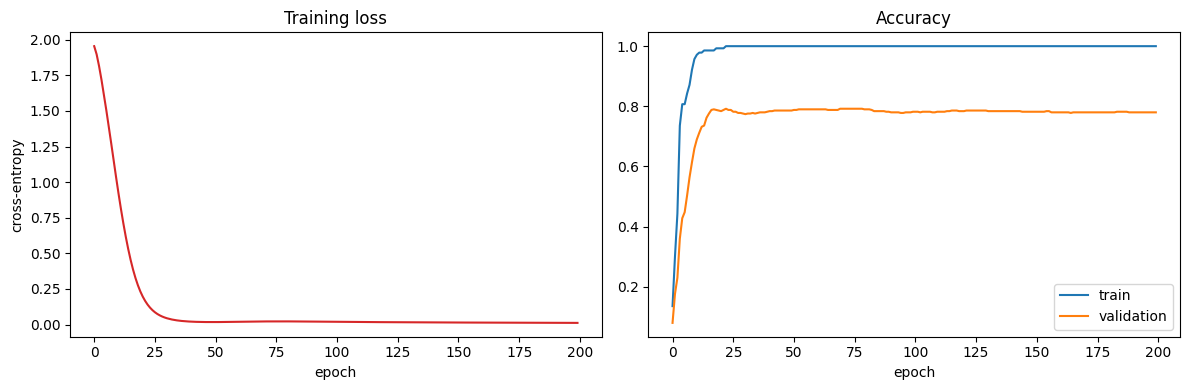

In [11]:
def train_model(A_input, nhid=16, epochs=200, lr=0.01, weight_decay=5e-4, seed=SEED):
    """Train a 2-layer GCN; pass A_input=A_hat for a real GCN, or I for an MLP."""
    torch.manual_seed(seed)
    model = GCN(cora.num_node_features, nhid, cora.num_classes)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"loss": [], "train_acc": [], "val_acc": []}
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out, _ = model(data.x, A_input)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        opt.step()
        with torch.no_grad():
            pred = out.argmax(1)
            hist["loss"].append(loss.item())
            hist["train_acc"].append(
                (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item())
            hist["val_acc"].append(
                (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item())
    return model, hist


def evaluate(model, A_input):
    model.eval()
    with torch.no_grad():
        out, hidden = model(data.x, A_input)
        pred = out.argmax(1).numpy()
    yt = data.y[data.test_mask].numpy()
    acc = accuracy_score(yt, pred[data.test_mask.numpy()])
    f1 = f1_score(yt, pred[data.test_mask.numpy()], average="macro")
    return acc, f1, pred, hidden


gcn, hist = train_model(A_hat)
gcn_acc, gcn_f1, gcn_pred, gcn_hidden = evaluate(gcn, A_hat)
print(f"GCN  —  test accuracy {gcn_acc:.3f}   macro-F1 {gcn_f1:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["loss"], color="C3"); ax1.set_title("Training loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy")
ax2.plot(hist["train_acc"], label="train"); ax2.plot(hist["val_acc"], label="validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout()
plt.show()


The GCN reaches a **test accuracy of about 0.81** (macro-F1 ≈ 0.80) across all
seven topics — from only 140 labels. Is that the *graph's* doing, or could a plain
classifier on the same 1,433 content words have done as well?

We can answer cleanly because of how we wrote the layer. Set the propagation
matrix to the **identity** $I$ instead of $\hat{A}$, and $H' = \sigma(I\,H\,W) =
\sigma(H\,W)$ — the neighbours drop out and the model becomes an ordinary
**multilayer perceptron (MLP)** that sees each paper *in isolation*. Same
features, same depth, same training; the **only** difference is whether messages
flow along edges.


The picture makes the control exact. Both models are the **same two-layer
network**; the only thing that changes is the matrix $M$ plugged into every
propagation step.

```mermaid
flowchart TB
    X["H = data.x · N×1433<br/>word features (same for both models)"]
    X --> L1["Layer 1:  × W₁ (1433→16)  →  × M  →  ReLU"]
    L1 --> Hh["H' · N×16  (hidden embeddings)"]
    Hh --> L2["Layer 2:  × W₂ (16→7)  →  × M"]
    L2 --> Z["scores · N×7"]
    Z --> P["argmax → predicted topic"]
    M["M — the one knob we change<br/>M = Â  →  GCN (blend along citations)<br/>M = I  →  MLP (each paper in isolation)"]
    M -.-> L1
    M -.-> L2
    style M fill:#fff3cd,stroke:#d39e00
```

Notice **where the words enter**: `data.x` — the 1,433-word bag-of-words — is the
*input to layer 1 in both models*, so the MLP still learns from the words.
Swapping $\hat{A}\to I$ does **not** delete the features; it deletes the *neighbour
mixing* (since $I\,(HW)=HW$), leaving each paper to be classified on its own words
alone. Everything else — the features, the two learnable maps $W_1,W_2$, the
ReLU, the optimiser, the 200 epochs — is identical, so the accuracy gap below is
attributable to the graph and nothing else.


MLP (no graph) — test accuracy 0.542   macro-F1 0.534
GCN (graph)    — test accuracy 0.808   macro-F1 0.802


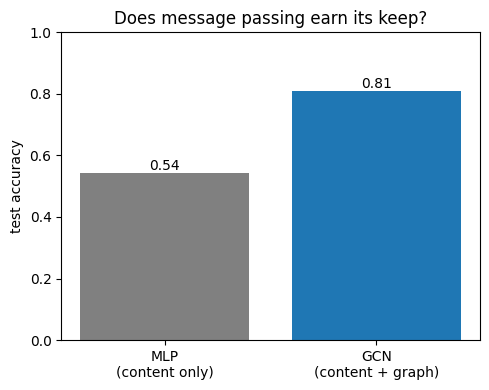

In [12]:
I_N = torch.eye(N)                      # identity -> no message passing
mlp, _ = train_model(I_N)
mlp_acc, mlp_f1, _, _ = evaluate(mlp, I_N)
print(f"MLP (no graph) — test accuracy {mlp_acc:.3f}   macro-F1 {mlp_f1:.3f}")
print(f"GCN (graph)    — test accuracy {gcn_acc:.3f}   macro-F1 {gcn_f1:.3f}")

plt.figure(figsize=(5, 4))
bars = plt.bar(["MLP\n(content only)", "GCN\n(content + graph)"],
               [mlp_acc, gcn_acc], color=["gray", "C0"])
for b, v in zip(bars, [mlp_acc, gcn_acc]):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center")
plt.ylabel("test accuracy"); plt.ylim(0, 1)
plt.title("Does message passing earn its keep?")
plt.tight_layout()
plt.show()


**The verdict.** Same words, same model — but wiring in the graph lifts test
accuracy from about **0.54** to about **0.81**, roughly **27 points**. With only
140 labels, an MLP barely beats a coin-flip-among-seven; the GCN's edges let each
paper borrow evidence from the papers it cites, and a sparse handful of labels
spreads across the whole network.

This is the precise answer to the question Chapter 9 left open: *what does a GNN
get to learn that we fixed by hand?* It learns features that **already fold in the
neighbourhood**, so we never have to invent a "mean-neighbour-degree" column — the
averaging is the model.

To *see* what the GCN learned, we project two things to 2-D with t-SNE and colour
by topic: the **raw** 1,433-word features (what the MLP sees) and the GCN's
**hidden-layer embeddings** (what message passing produced).


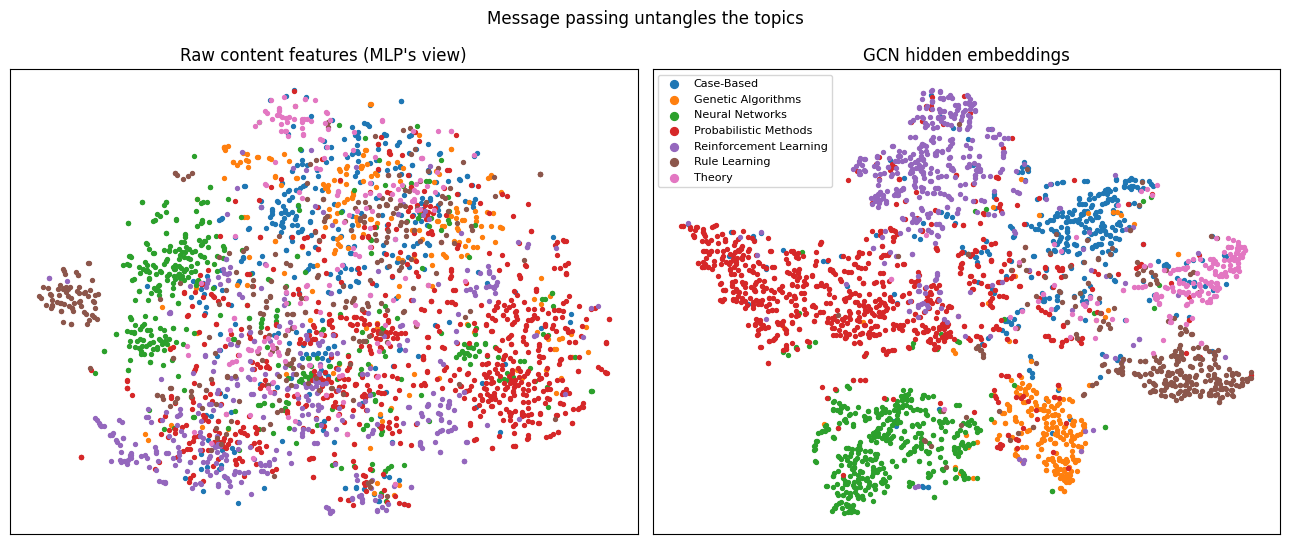

In [13]:
def tsne_2d(M, seed=SEED):
    M = M.detach().numpy() if torch.is_tensor(M) else np.asarray(M)
    if M.shape[1] > 50:                       # PCA first to speed up / denoise t-SNE
        M = PCA(n_components=50, random_state=seed).fit_transform(M)
    return TSNE(n_components=2, init="pca", random_state=seed,
                perplexity=30).fit_transform(M)


raw_2d = tsne_2d(data.x)
gcn_2d = tsne_2d(gcn_hidden)
y_all = data.y.numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, coords, title in [(axes[0], raw_2d, "Raw content features (MLP's view)"),
                          (axes[1], gcn_2d, "GCN hidden embeddings")]:
    for c in range(cora.num_classes):
        m = y_all == c
        ax.scatter(coords[m, 0], coords[m, 1], s=8, label=class_names[c])
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, fontsize=8, loc="best")
fig.suptitle("Message passing untangles the topics")
plt.tight_layout()
plt.show()


On the left, the raw word vectors are a single diffuse cloud — neighbouring topics
overlap heavily, which is why the MLP struggles. On the right, after two rounds of
message passing the same papers fall into **seven visibly separated islands**,
one per topic. The GCN did not get new information; it **reorganised** what was
there by letting each paper average toward its citation neighbourhood.

> **The graph is not a feature you add — it is a lens that reshapes every feature
> you already have.**


### 🖐️ Your turn: resize the hidden layer

The GCN's hidden width is `nhid=16`.

In [14]:
# 🖐️ Retrain the GCN with a wider (nhid=64) or narrower (nhid=4) hidden layer
#    and read off the test accuracy. Does more width help much here?
# Hint: train_model(A_hat, nhid=64) -> evaluate(model, A_hat).
# TODO: train one alternative width and print its test accuracy next to 0.81.


### 🖐️ Your turn: why normalise? (~10 min)

§10.3 made two changes to plain averaging: **self-loops** and **symmetric degree
normalisation**. How much does the normalisation actually buy us? Train the GCN
on the **un-normalised** propagation $\tilde{A} = A + I$ (self-loops only, no
$\tilde{D}^{-1/2}$ scaling), compare its test accuracy to the normalised model,
and say in one sentence what the normalisation is doing.

In [15]:
# 🖐️ Build the self-loops-only matrix A_tilde (no degree normalization), feed it to
#    train_model / evaluate, and compare its test accuracy to the normalized GCN (~0.81).
# Hint: A_tilde was computed in §10.3 as A + I; just reuse it as A_input.
# TODO: train a GCN on A_tilde, print its test accuracy, and compare to gcn_acc.


<details><summary>Solution</summary>

```python
gcn_unnorm, _ = train_model(A_tilde)            # A_tilde = A + I, no D^-1/2
unnorm_acc, _, _, _ = evaluate(gcn_unnorm, A_tilde)
print(f"un-normalized {unnorm_acc:.3f}   vs   normalized {gcn_acc:.3f}")
```

The un-normalised GCN scores about **0.745**, roughly **6 points** below the
normalised **0.808**. Without $\tilde{D}^{-1/2}$, every layer multiplies
high-degree nodes' values by their (large) degree, so the activations blow up and
the optimiser fights the scale instead of the signal. Symmetric normalisation
keeps each node's mixed feature on a comparable scale, which is what lets the two
layers stack cleanly.
</details>


## 10.5 What breaks, and where GNNs go next

If two rounds of message passing help, why not ten? Because the smoothing we saw
on the toy graph (§10.2) eventually goes too far. Apply $\hat{A}$ to Cora's
features again and again, with no training in between, and measure how **similar**
the node vectors become (mean cosine similarity between all pairs). They start
nearly orthogonal and steadily collapse toward identical.


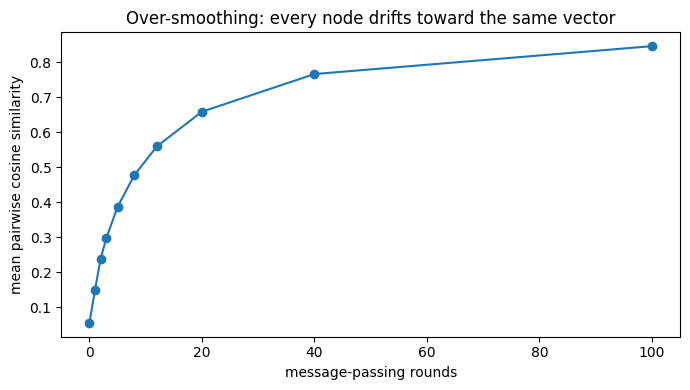

raw features: 0.056   after 100 rounds: 0.846


In [16]:
def mean_pairwise_cosine(H):
    Hn = F.normalize(H, dim=1)
    S = Hn @ Hn.t()
    return ((S.sum() - torch.diagonal(S).sum()) / (N * N - N)).item()


steps = [0, 1, 2, 3, 5, 8, 12, 20, 40, 100]
sims = []
for k in steps:
    Hk = data.x.clone()
    for _ in range(k):
        Hk = A_hat @ Hk
    sims.append(mean_pairwise_cosine(Hk))

plt.figure(figsize=(7, 4))
plt.plot(steps, sims, marker="o")
plt.xlabel("message-passing rounds")
plt.ylabel("mean pairwise cosine similarity")
plt.title("Over-smoothing: every node drifts toward the same vector")
plt.tight_layout()
plt.show()
print(f"raw features: {sims[0]:.3f}   after 100 rounds: {sims[-1]:.3f}")


The average similarity climbs from about **0.06** (raw features barely overlap) to
about **0.85** (every paper looks almost the same). A model whose nodes are all
identical cannot tell topics apart — this is **over-smoothing**, and it is why
classic GCNs are **shallow**, typically 2–3 layers. (The homework's depth sweep
makes the cost concrete: accuracy slips from ≈ 0.81 at 2 layers to ≈ 0.20 at 8.)

One more loose end. We built our `GCNLayer` by hand to *understand* it — but it is
exactly the layer Chapter 7 imported as a black box. PyTorch Geometric ships it as
`GCNConv`; swapping our layer for the library's gives the same result.


In [17]:
from torch_geometric.nn import GCNConv


class PyGGCN(nn.Module):
    def __init__(self, nfeat, nhid, nclass):
        super().__init__()
        self.conv1 = GCNConv(nfeat, nhid)
        self.conv2 = GCNConv(nhid, nclass)

    def forward(self, x, edge_index):
        return self.conv2(F.relu(self.conv1(x, edge_index)), edge_index)


torch.manual_seed(SEED)
pyg_model = PyGGCN(cora.num_node_features, 16, cora.num_classes)
opt = torch.optim.Adam(pyg_model.parameters(), lr=0.01, weight_decay=5e-4)
for _ in range(200):
    pyg_model.train(); opt.zero_grad()
    out = pyg_model(data.x, data.edge_index)
    F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward()
    opt.step()
pyg_model.eval()
with torch.no_grad():
    pyg_pred = pyg_model(data.x, data.edge_index).argmax(1).numpy()
pyg_acc = accuracy_score(data.y[data.test_mask].numpy(), pyg_pred[data.test_mask.numpy()])
print(f"PyG GCNConv test accuracy {pyg_acc:.3f}   vs   from-scratch {gcn_acc:.3f}")


PyG GCNConv test accuracy 0.804   vs   from-scratch 0.808


The two land within a point of each other — our hand-built layer **is** the real
GCN. In practice you would always reach for the library version: it is faster,
uses sparse operations (no dense $N \times N$ matrix), and runs on a GPU.

**Where this goes next.** The GCN is the first and simplest GNN; the rest of the
book builds on it.

- The mean aggregator is one choice. **GraphSAGE** samples and pools neighbours so
  it scales to huge graphs; **Graph Attention Networks (GAT)** *learn* how much
  weight to give each neighbour instead of fixing it by degree.
- The same message-passing machinery powers the other graph tasks from §7.1:
  **link prediction** (Chapter 11), **unsupervised and semi-supervised learning**
  (Chapter 12), **explaining** what a GNN learned (Chapter 13), and pooling node
  embeddings into a **whole-graph** prediction (Chapter 14).

> **Every GNN in this book is a variation on one theme: pass messages along edges,
> transform, repeat. Change the aggregator or the read-out, and you change the
> task.**


## Summary

- **A GNN learns features instead of you.** Chapters 7–9 built a feature table by
  hand or with Node2Vec and then classified; a GNN fuses both steps into one model
  trained end to end on the graph.
- **Message passing is the whole idea.** Repeatedly replace each node's vector with
  a summary of its neighbours'. One round reaches 1 hop, $k$ rounds reach $k$ hops.
- **A GCN layer is message passing made well-behaved:** add self-loops so a node
  keeps itself, normalise by $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ so hubs
  don't dominate, then apply a learnable linear map and a nonlinearity —
  $H' = \sigma(\hat{A} H W)$.
- **On Cora, the graph is worth ~27 points.** From only 140 labels, a 2-layer GCN
  reached test accuracy ≈ 0.81 (macro-F1 ≈ 0.80); the same network with the edges
  removed (an MLP on the same words) managed only ≈ 0.54. t-SNE showed the GCN
  reorganising one diffuse cloud into seven topic islands.
- **Depth has a ceiling.** Too many rounds *over-smooth* — every node converges to
  the same vector (cosine similarity ≈ 0.85 after 100 rounds), so GCNs stay
  shallow.
- **Our from-scratch layer is the real thing:** it matches PyG's `GCNConv` to
  within a point, and the same machinery carries forward to link prediction
  (Ch 11), unsupervised/semi-supervised learning (Ch 12), explainability (Ch 13),
  and graph-level learning (Ch 14).


## 🌶️ Bonus exercises (only if time remains)

These are optional extensions for the end of class — pick whichever looks fun. Each
is a bit larger and more open-ended than the in-class "Your turn" tasks (~15–25 min).


### 🌶️ Bonus 1 — How deep is too deep?

§10.5 showed that *propagating* features forever flattens them (over-smoothing).
Does that actually hurt a *trained* model? Sweep the GCN's **depth** from 2 to 8
layers, record the test accuracy at each, and plot accuracy versus number of
layers. Where is the sweet spot, and where does the model fall off a cliff? Answer
with a one-line verdict.


In [18]:
# 🌶️ Train a GCN at several depths and plot test accuracy vs. number of layers.
# A variable-depth model is set up for you; you write the sweep.

class GCNDeep(nn.Module):
    def __init__(self, nfeat, nhid, nclass, n_layers):
        super().__init__()
        sizes = [nfeat] + [nhid] * (n_layers - 1) + [nclass]
        self.layers = nn.ModuleList(
            GCNLayer(sizes[i], sizes[i + 1]) for i in range(n_layers)
        )

    def forward(self, X, A_hat):
        h = X
        for layer in self.layers[:-1]:
            h = F.relu(layer(h, A_hat))
        return self.layers[-1](h, A_hat)


depths = [2, 3, 4, 6, 8]
# Hint: for each depth, train GCNDeep(...) on (data.x, A_hat) like train_model does
#       (Adam, lr=0.01, weight_decay=5e-4, 200 epochs), then score on data.test_mask.
# TODO: collect a test accuracy per depth, plot acc vs depth, and name the collapse point.


<details><summary>Solution</summary>

```python
def train_deep(n_layers, epochs=200):
    torch.manual_seed(SEED)
    model = GCNDeep(cora.num_node_features, 16, cora.num_classes, n_layers)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        out = model(data.x, A_hat)
        F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(data.x, A_hat).argmax(1).numpy()
    return accuracy_score(data.y[data.test_mask].numpy(), pred[data.test_mask.numpy()])

accs = [train_deep(d) for d in depths]
plt.plot(depths, accs, marker="o")
plt.xlabel("number of GCN layers"); plt.ylabel("test accuracy")
plt.title("Deeper is not better"); plt.show()
print(dict(zip(depths, [round(a, 3) for a in accs])))
```

Test accuracy drifts down gently and then collapses: **0.808 → 0.788 → 0.767 →
0.715 → 0.196** for 2, 3, 4, 6 and 8 layers. Two layers is the sweet spot; past
about four the over-smoothing of §10.5 takes over, and by eight layers every node
has blurred into nearly the same vector, so accuracy falls to ≈ 0.20 — barely above
random. More depth buys *reach* but pays in *resolution*, the opposite of deep
image CNNs, which is why GCNs stay shallow.
</details>


### 🌶️ Bonus 2 — Does it hold on a different graph?

On Cora the graph added ~27 points. Is that a fluke of one dataset? Repeat the
§10.4 **GCN-vs-MLP controlled experiment** on **CiteSeer** — another citation
network PyG ships through `Planetoid` (3,327 papers, 6 topics). Build its
normalised adjacency the same way, train both models, and compare the gap to
Cora's. Does message passing still earn its keep — and is the margin bigger or
smaller?


In [19]:
# 🌶️ Re-run the §10.4 controlled experiment (GCN vs MLP) on CiteSeer.
# Planetoid is already imported. CiteSeer has the same shape of data as Cora:
# cite[0] gives .x, .edge_index, .y and train/val/test masks.
# Hint: mirror §10.3 to build CiteSeer's A_hat (self-loops + symmetric normalization),
#       then mirror §10.4 — train one GCN on A_hat and one MLP on torch.eye(Nc).
# TODO: print CiteSeer's GCN and MLP test accuracies and compare the gap to Cora's ~27 pts.


<details><summary>Solution</summary>

```python
cite = Planetoid(root="/tmp/CiteSeerFull", name="CiteSeer")
cdata = cite[0]; Nc = cdata.num_nodes

Ac = torch.zeros((Nc, Nc)); Ac[cdata.edge_index[0], cdata.edge_index[1]] = 1.0
Ac = ((Ac + Ac.t()) > 0).float()
Ac_tilde = Ac + torch.eye(Nc); dc = Ac_tilde.sum(1)
Ac_hat = torch.diag(dc.pow(-0.5)) @ Ac_tilde @ torch.diag(dc.pow(-0.5))

def fit_eval(A_input):
    torch.manual_seed(SEED)
    model = GCN(cite.num_node_features, 16, cite.num_classes)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    for _ in range(200):
        model.train(); opt.zero_grad()
        out, _ = model(cdata.x, A_input)
        F.cross_entropy(out[cdata.train_mask], cdata.y[cdata.train_mask]).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(cdata.x, A_input)[0].argmax(1).numpy()
    return accuracy_score(cdata.y[cdata.test_mask].numpy(), pred[cdata.test_mask.numpy()])

print("CiteSeer GCN:", round(fit_eval(Ac_hat), 3))
print("CiteSeer MLP:", round(fit_eval(torch.eye(Nc)), 3))
```

On CiteSeer the GCN scores **0.683** versus the MLP's **0.560** — the graph still
helps, by about **12 points**. The pattern holds on a second dataset, so it is not
a Cora quirk; the smaller margin (12 vs 27 points) reflects CiteSeer's sparser,
noisier citation structure, which gives message passing less to lean on. The lesson
generalises: **wiring in the graph helps whenever the edges carry signal — and how
much depends on how strong that signal is.**
</details>


## Chapter 10 — Introduction to Graph Neural Networks (GNNs) · Homework

Work in a copy of this notebook and reuse its data, `train_model`, and `evaluate`.
Hand in your code, any figures, and **a sentence or two of interpretation per
part** — the interpretation is what's graded.

### Part A — Reach equals depth
A 2-layer GCN lets a node see its 2-hop neighbourhood. Verify this directly:
compute $\hat{A}^2$ (matrix power) and pick a low-degree node; show that its
non-zero entries in $\hat{A}$ correspond to 1-hop neighbours and in $\hat{A}^2$ to
nodes within 2 hops. Then explain, in one or two sentences, why "more layers =
more reach" runs into the over-smoothing wall from §10.5.

### Part B — Content vs. structure (the controlled experiment)
You have already compared **content + graph** (the GCN, ≈ 0.81) with **content, no
graph** (the MLP, ≈ 0.54). Add a third model: **structure, no content** — replace
`data.x` with the identity matrix `torch.eye(N)` (so each node's only "feature" is
its own id) and train a GCN on it. Report all three test accuracies. What does
each model isolate, and which matters more on Cora — what a paper *says* or who it
*cites*?

### Part C — Label efficiency (the bridge forward)
The GCN's edge over the MLP comes from spreading a few labels across the graph.
Shrink the training set — keep only the first $k \in \{1, 3, 5, 10, 20\}$ labelled
nodes per class — retrain both the GCN and the MLP at each $k$, and plot test
accuracy versus $k$. At what point does the GCN stop beating the MLP, if ever?
Relate your curve to **semi-supervised learning**, the subject of Chapter 12.
